# Redlining at the National Level Analysis

## Introduction to Redlining Specific Data

How did the Home Owners Loan Corporation (HOLC) practice of redlining create deeply ingrained patterns of racial as well as economic segregation that were resistant to the progressive legislation meant to mitigate the long-term impacts of redlining? This section of the project aims to answer this question by analyzing the long-term effects of redlining by creating three distinct but connected time series featuring data on racial composition, homeownership rates, and home & rent value across HOLC neighborhood grades. Our results showcase how the prejudicial redlining policies created long-lasting barriers that hindered the economic prosperity of African American families for generations.

The dataset spans 1910 to 2010, capturing key events in America's residential real estate policy. During the 1930s, the federally-backed HOLC formed, marking the beginning of discriminatory mortgage lending practices known as "redlining" through the restriction of financing for minorities by separating neighborhoods through varying degrees of riskiness. It also captures key events, such as the Great Migration, where the North increased residential demand, and the subsequent Civil Rights era which prohibited racial segregation. The data concludes two decades after the 1968 Fair Housing Act, which prohibited residential discrimination, formally ending redlining. Despite redlining ending in 1968, the span of the time series and its supporting historical context provide the basis for an analysis investigating redlining's effects on African Americans and the limitations of rectification through anti-discriminatory policies.

The visualizations use historical data from the Federal Reserve Economic Data (FRED) database on the aforementioned three metrics. The database standardizes monetary values to 2010 dollars and matches U.S. Census data with corresponding geocoded HOLC Neighborhoods. The visuals were created using Python and included a color scheme depicting the four grades and their respective perceived financial riskiness. The solid lines indicate the primary group/variable (i.e. African Americans or Home Value), while the dashed lines represent the secondary measurement (Foreign Born or Rent).

The visualizations work together by demonstrating the enduring nature of the effects of redlining. The racial composition graph showcases the association between HOLC grades and institutionalized segregation reflected by the staggering increase in African American concentration in Grade D housing. The homeownership graphs illustrate how the resulting racial segregation transformed into greater wealth accumulation setbacks for African American families. The home value graph completes the analysis by ascertaining that the effects go beyond diverging values and connect the disparities in African American families' ability to save, quality of education, and the psychological implication of long-term housing valuation.

When combined, the visuals demonstrate that by 1968, the resulting inequalities of systemic racism had been so deeply rooted in society that ending explicit discrimination was insufficient. Calling for the need for active intervention, otherwise the self-reinforcing historical patterns will continue to restrict opportunity and economic prosperity for generations of African Americans.



In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import statsmodels.api as sm
import warnings
import os
!pip install openpyxl
warnings.filterwarnings('ignore', message='is not UTF-8 encoded')

data_dir = Path("final-group10/data")


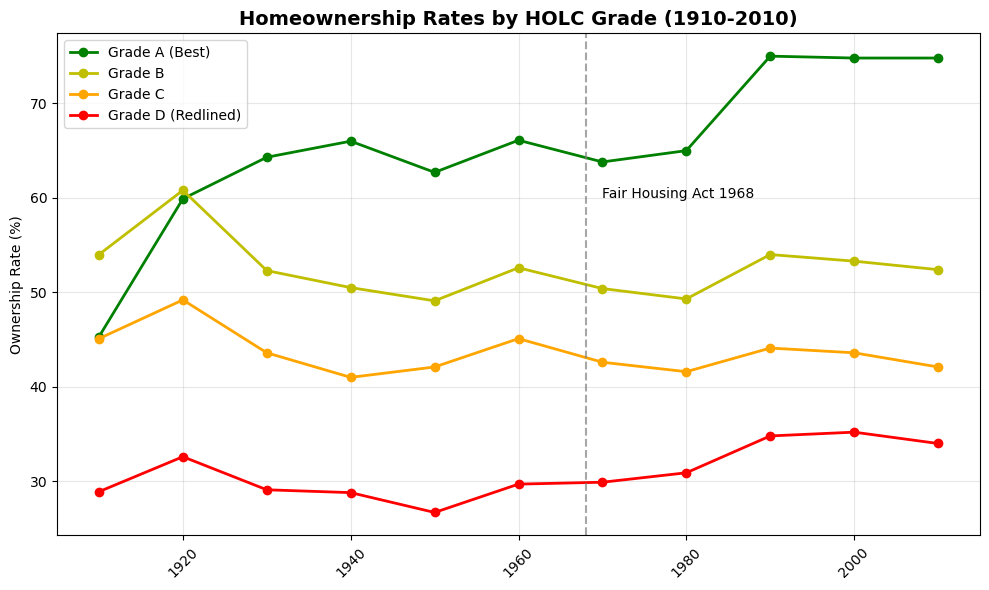

In [24]:
import matplotlib.pyplot as plt
df_ownership = pd.read_excel("../data/ownership_rate_HOLC.xlsx")
plt.figure(figsize=(10, 6))
plt.plot(df_ownership['observation_date'], df_ownership['A'], 'go-', label='Grade A (Best)', linewidth=2)
plt.plot(df_ownership['observation_date'], df_ownership['B'], 'yo-', label='Grade B', linewidth=2)
plt.plot(df_ownership['observation_date'], df_ownership['C'], 'o-', color='orange', label='Grade C', linewidth=2)
plt.plot(df_ownership['observation_date'], df_ownership['D'], 'ro-', label='Grade D (Redlined)', linewidth=2)

plt.axvline(pd.to_datetime('1968-01-01'), color='gray', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('1970-01-01'), 60, 'Fair Housing Act 1968', rotation=0)

plt.title('Homeownership Rates by HOLC Grade (1910-2010)', fontsize=14, fontweight='bold')
plt.ylabel('Ownership Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/ownership_simple.png', dpi=300, bbox_inches='tight')
plt.show()


The homeownership time series demonstrates the long-lasting barriers induced by redlining that severely limited economic mobility and wealth accumulation.

Between the years 1930 to 2010, considerable and consistent gaps emerged between homeownership rates. Residents of Grade A housing were occupied by their owners 75% of the time, while Grade D residents remained consistently suppressed below 35%. This clear contrast represents a systemic rejection of the fundamental wealth-accumulating opportunity for 20th-century Americans.

This alarming 33.4 percentage point between Grade A and D neighborhoods was indicative of the long-lasting nature of redlining, as while White Americans living in Grade A housing were able to accumulate intergenerational wealth through home equity, African American families were trapped in a positive feedback loop of rent cycling.

This polarity continued to be reinforced by the contrasting school quality, creating cycles of diverging municipal investment, leaving affluent families unwilling to move in and reside in Grade D and C neighborhoods.



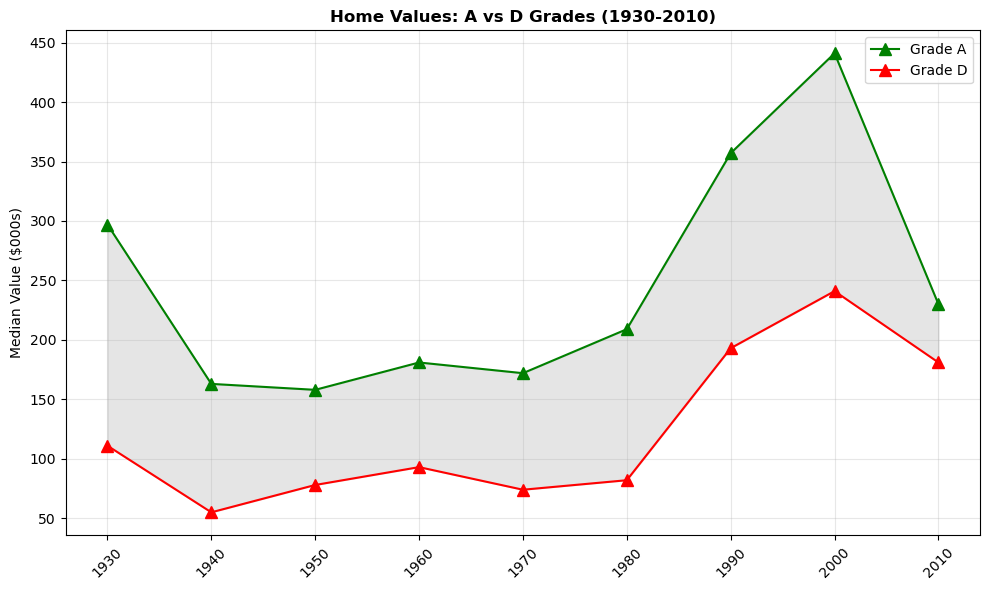

In [25]:
df_median = pd.read_excel("../data/median_value_HOLC.xlsx")

plt.figure(figsize=(10, 6))
plt.plot(df_median['observation_date'], df_median['A'], 'g^-', label='Grade A', markersize=8)
plt.plot(df_median['observation_date'], df_median['D'], 'r^-', label='Grade D', markersize=8)
plt.fill_between(df_median['observation_date'], df_median['A'], df_median['D'], alpha=0.2, color='gray')

plt.title('Home Values: A vs D Grades (1930-2010)', fontweight='bold')
plt.ylabel('Median Value ($000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/home_values_gap.png', dpi=300)
plt.show()

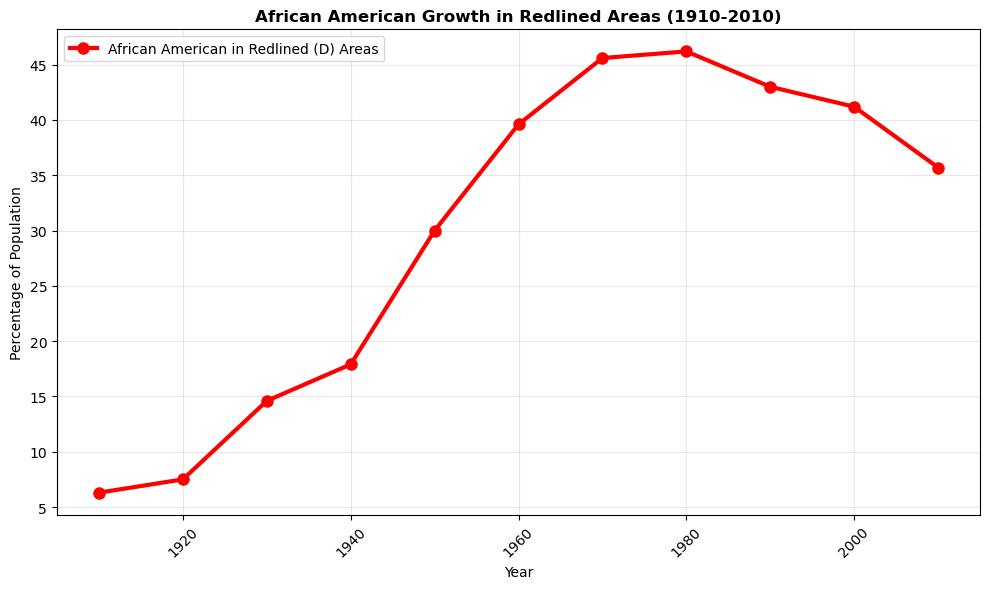

In [26]:
# Clean the messy headers skip first row use real column names
df_demo = pd.read_excel("../data/share_of_African_Americans_and_Foreign_Born_HOLC.xlsx", 
                        skiprows=1)  # Skip the frequency 10 Year row
df_demo.columns = ['date', 'FB_D', 'FB_A', 'FB_B', 'FB_C', 'AA_A', 'AA_B', 'AA_C', 'AA_D']

plt.figure(figsize=(10, 6))
plt.plot(df_demo['date'], df_demo['AA_D'], 'ro-', linewidth=3, markersize=8, 
         label='African American in Redlined (D) Areas')

plt.title('African American Growth in Redlined Areas (1910-2010)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/aa_redlined_growth.png', dpi=300)
plt.show()

Here we see a distnict increase in the percentage of the population of African Americans in redlined areas, the increase post the 1930s implementation of HOLC redlining is clrease and remains persistent showcasing how African Americans were essentially pushed out from Grade A neighborhoods. The subsequent figures explain the mechanisms behind this increase and compare the concentration of African Americans in redlined vs non-redlined neighborhoods to Foreign Born Americans.

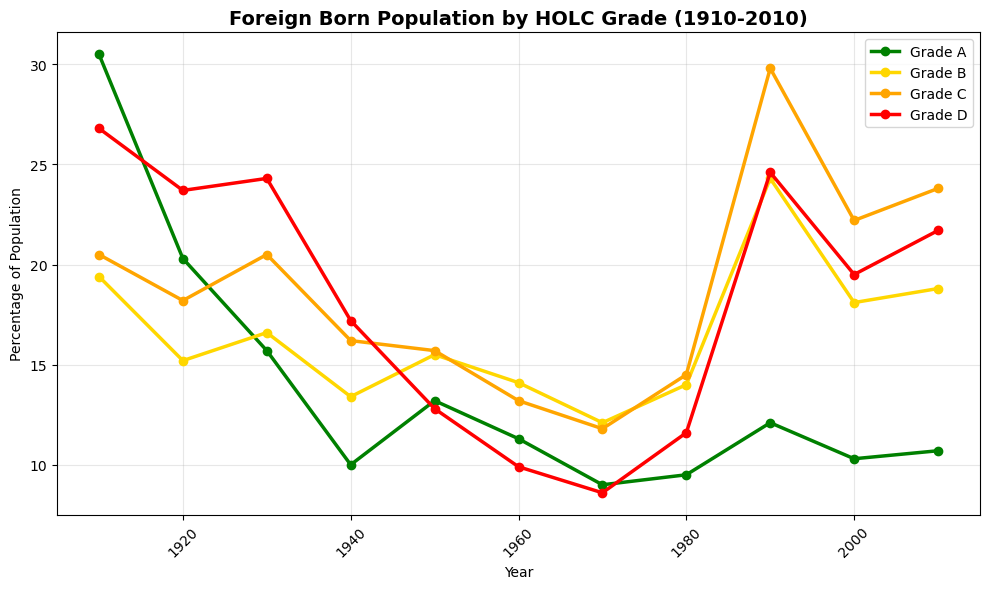

In [27]:
plt.figure(figsize=(10, 6))
grade_colors = {'A': 'green', 'B': 'gold', 'C': 'orange', 'D': 'red'}

for grade in ['A', 'B', 'C', 'D']:
    col = f"FB_{grade}"
    plt.plot(df_demo['date'], df_demo[col], 
             marker='o', linestyle='-', color=grade_colors[grade], 
             linewidth=2.5, markersize=6, label=f'Grade {grade}')

plt.title('Foreign Born Population by HOLC Grade (1910-2010)', fontweight='bold', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/foreign_born_by_grade.png', dpi=300, bbox_inches='tight')
plt.show()


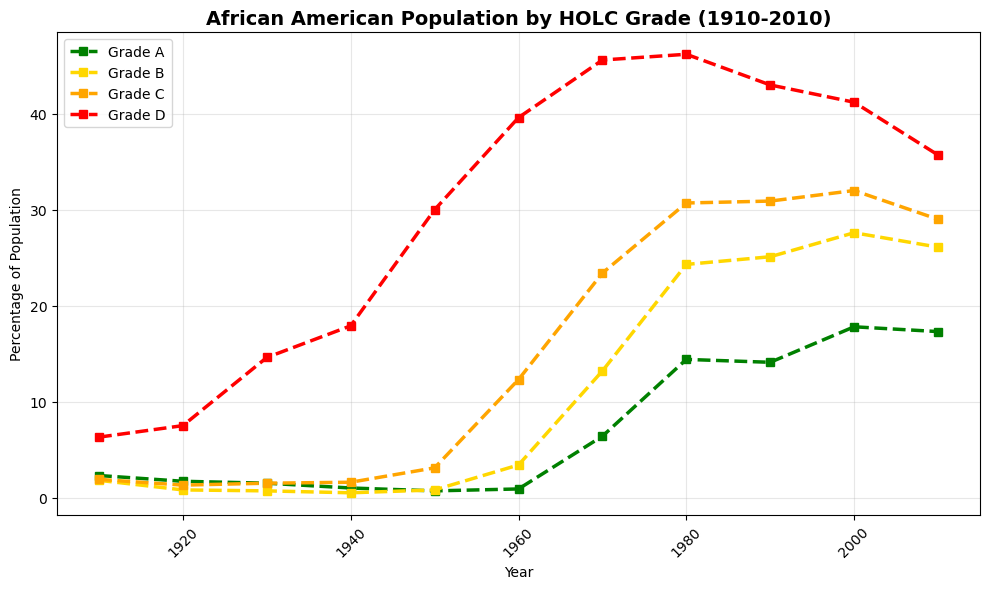

In [28]:
plt.figure(figsize=(10, 6))
grade_colors = {'A': 'green', 'B': 'gold', 'C': 'orange', 'D': 'red'}

for grade in ['A', 'B', 'C', 'D']:
    col = f"AA_{grade}"
    plt.plot(
        df_demo['date'],
        df_demo[col],
        marker='s',
        linestyle='--',
        color=grade_colors[grade],
        linewidth=2.5,
        markersize=6,
        label=f'Grade {grade}'
    )

plt.title('African American Population by HOLC Grade (1910-2010)', fontweight='bold', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/african_american_by_grade.png', dpi=300, bbox_inches='tight')
plt.show()


Both these figures dipicting the racial composition time series of both African and Americans and Foreign Born is critical in illustrating redlining’s role in reshaping prejudice into systemic segregation. Grade D neighborhoods saw a considerable increase in the African American composition (6% to 43%), contrasting the minor increase in Grade A neighborhoods (2% to 14%) from 1910 to 1990, demonstrating how redlining led to persistent patterns of racial segregation. These increasing disparities are evidence attributing the self-reinforcing nature of blockbusting efforts that exacerbated the effects of white flight and the restriction of financial services to African Americans to the resulting inequality. The neighborhood variation (range) of Foreign Born (predominantly White European) was considerably less compared to their African American counterparts (3.5 pp v.s. 39 pp for the year 1970). Revealing that European immigrants gained increasing mobility while African Americans remained confined. This contrast contextualizes how redlining led to a systemic evolution of determining which ethnic groups were considered “white” and obtaining access to “white privilege, ” shaping redlining’s role in defining race. Despite an “8 percentage point” increase in African American markup for Grade A neighborhoods post-Fair Housing Act, analyzing the results of the Difference-in-Difference test’s statistically insignificant p-value (0.492) indicates that the “Fair Housing Act” and other egalitarianistic legislation failed to reduce the segregational inequality amongst HOLC neighborhoods. Ultimately showing that these persistent patterns from redlining were deeply ingrained to the point that rectifying segregational inequality requires more than anti-discriminatory laws, highlighting the need for an effective interventionist approach to combat decades of institutionalized discrimination.

In [29]:
# Clean rent data (A vs D only)
df_rent = pd.read_excel("../data/rent_and_rental_costs_in_HOLC.xls", skiprows=1)
df_rent.columns = ['date', 'rent_A', 'rent_D']  

/tmp/ipykernel_848/354147005.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--s" (-> color='g'). The keyword argument will take precedence.
  ax1.plot(df_rent['date'], df_rent['rent_A'], 'g--s', linewidth=2.5, markersize=8, label='Rent Grade A', color=grade_colors['A'])
/tmp/ipykernel_848/354147005.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--o" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(df_rent['date'], df_rent['rent_D'], 'r--o', linewidth=2.5, markersize=8, label='Rent Grade D', color=grade_colors['D'])
/tmp/ipykernel_848/354147005.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-o" (-> color='g'). The keyword argument will take precedence.
  ax2.plot(df_median['observation_date'], df_median['A'], 'g-o', linewidth=2.5, markersize=8, label='Home Value A', color=grade_colors['A'])
/tmp/ipykernel_

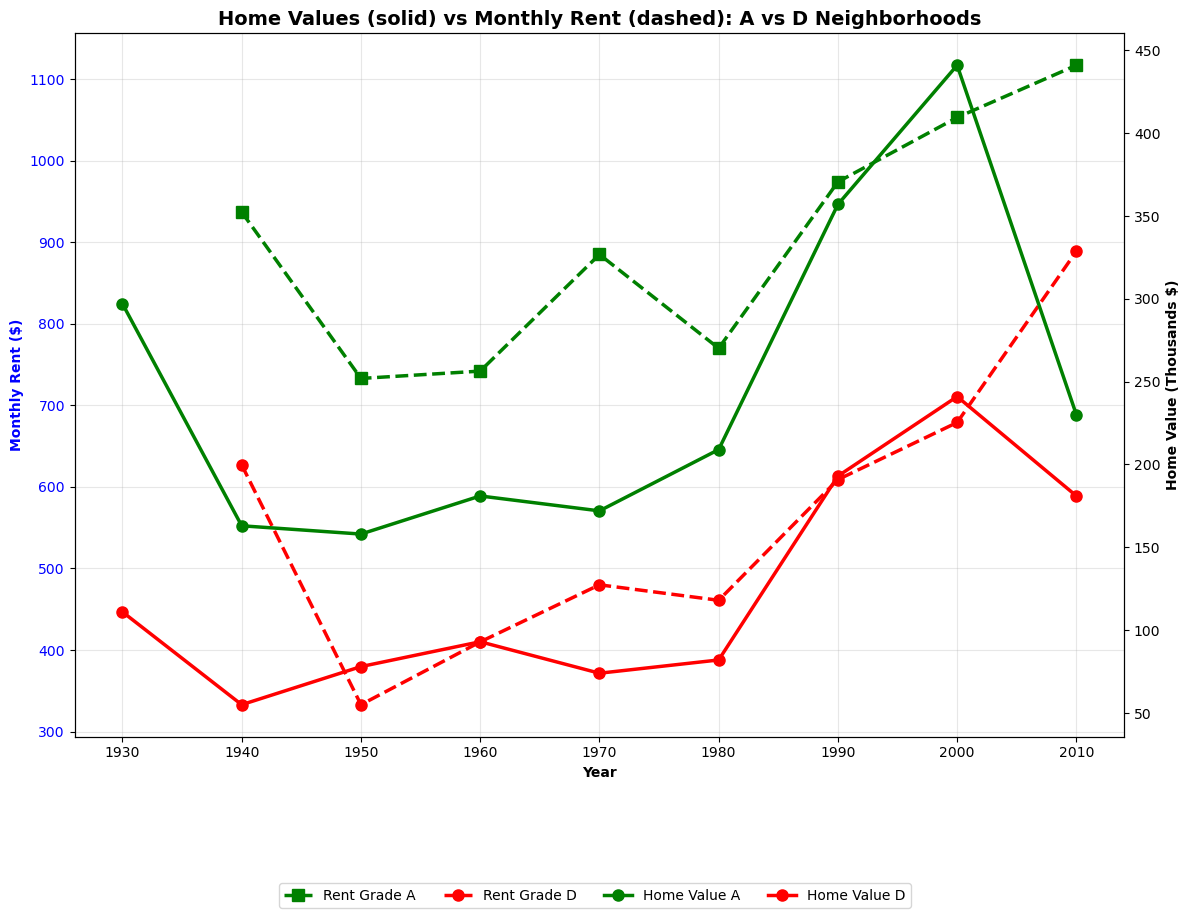

In [30]:
fig, ax1 = plt.subplots(figsize=(12, 8))

grade_colors = {'A': 'green', 'D': 'red'}

# Rent is left axis with dashed lines matching neighborhood colors
ax1.plot(df_rent['date'], df_rent['rent_A'], 'g--s', linewidth=2.5, markersize=8, label='Rent Grade A', color=grade_colors['A'])
ax1.plot(df_rent['date'], df_rent['rent_D'], 'r--o', linewidth=2.5, markersize=8, label='Rent Grade D', color=grade_colors['D'])
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Monthly Rent ($)', color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Home values are the right axis solid lines matching neighborhood colors
ax2 = ax1.twinx()
ax2.plot(df_median['observation_date'], df_median['A'], 'g-o', linewidth=2.5, markersize=8, label='Home Value A', color=grade_colors['A'])
ax2.plot(df_median['observation_date'], df_median['D'], 'r-o', linewidth=2.5, markersize=8, label='Home Value D', color=grade_colors['D'])
ax2.set_ylabel('Home Value (Thousands $)', color='black', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Home Values (solid) vs Monthly Rent (dashed): A vs D Neighborhoods', 
          fontweight='bold', fontsize=14)
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/home_rent_neighborhood_colors.png', dpi=300, bbox_inches='tight')
plt.show()


Here the dual time series of home values and rent reveals a clandestine system of wealth suppression that propagated through numerous interconnected mechanisms. Pre Anti-discriminatory legislation, the $123,000 initial gap between A-D housing value meant it was mathematically impossible for Grade D households to catch up, as even identical appreciation rates would widen this disparity. Despite Grade D residents paying lower nominal rents than their counterparts, they paid proportionally more of their income to rent. This resulted in redlined families paying more in rent than the costs of a would-be mortgage despite being denied home equity. Furthermore, the relative rental disparities represent a reduced ability to save and invest, creating generational economic hardship for Grade D residents. Conversely this shows that rent was transferred to affluent property owners outside Grade D areas, ultimately increasing the divide. These differing property values reduced the property tax bases effectively reducing local school funding and quality in Grade D areas. The differing quality of education combined with the limited ability to save for down payments prevented Grade D residents from intergenerationally economically prospering. Redlining continued to influence the housing market psychologically. Despite the Fair Housing Act, the lack of catch up which will later be quantified in the difference-in-differences analysis revealed that HOLC risk grading mechanisms became a self-fulfilling prophecy over time as the home values reflected their perceived false risk rather than the actual risk. Thus, the valuation of Grade D continued to follow the historic patterns of redlining and was not based on the true intrinsic value. Thus, the analysis of this time series indicates that redlining not only created intergenerational wealth disparities, but an entire economy that has a deeply ingrained racial hierarchy through seemingly neutral market mechanisms.

# Difference in Differences Analysis

In [31]:
home_did = pd.DataFrame({
    "year": df_median["observation_date"].dt.year,
    "A": df_median["A"],
    "D": df_median["D"]
})

# Keep the common 1930–2010 years
home_did = home_did[(home_did["year"] >= 1930) & (home_did["year"] <= 2010)]

# Put into long (A/D stacked) format
home_long = pd.melt(
    home_did,
    id_vars="year",
    value_vars=["A", "D"],
    var_name="grade",
    value_name="home_value"
)

home_long["treatment"] = (home_long["grade"] == "D").astype(int)
home_long["post_1968"] = (home_long["year"] >= 1968).astype(int)
home_long["treat_post"] = home_long["treatment"] * home_long["post_1968"]

home_long.head()


,year,grade,home_value,treatment,post_1968,treat_post
0,1930,A,297,0,0,0
1,1940,A,163,0,0,0
2,1950,A,158,0,0,0
3,1960,A,181,0,0,0
4,1970,A,172,0,1,0


Here, we prepare the dataset for our difference in differences analysis by first extracting the years from the home value dataset for Grades A and D and then creating the three DiD key variables of treatment (1 for Grade 1 (readline) and 0 for Grade A), post_1968 (true after the Fair housing Act) and treat_post for the interaction term.

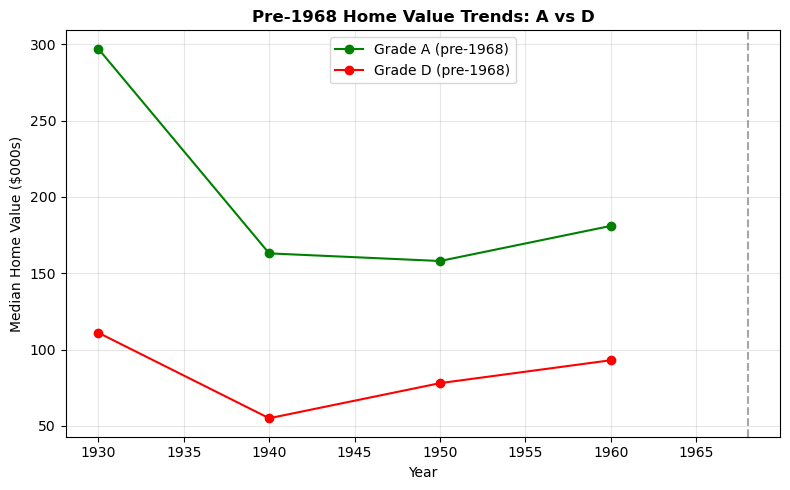

In [32]:
plt.figure(figsize=(8, 5))

pre = home_did[home_did["year"] < 1968]
post = home_did[home_did["year"] >= 1968]

plt.plot(pre["year"], pre["A"], 'g-o', label='Grade A (pre-1968)')
plt.plot(pre["year"], pre["D"], 'r-o', label='Grade D (pre-1968)')
plt.axvline(1968, color='gray', linestyle='--', alpha=0.7)

plt.title('Pre-1968 Home Value Trends: A vs D', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Home Value ($000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/home_values_parallel_check.png', dpi=300, bbox_inches='tight')
plt.show()


### Parallel Trends Verification
Here it can be see that before the implementation of the fair housing act, both the Grade A and Grade D neighborhoods have similar trendining values of their respective median home values with a steady decrease in the years 1930-1940 and a slight but steady growth from 1940 to 1960, though there is some varability it can be assume that these trends are reasonably parallel indicating that the differene-in-differences results can be applied.

In [33]:
import statsmodels.api as sm

X = home_long[["treatment", "post_1968", "treat_post"]]
X = sm.add_constant(X)
y = home_long["home_value"]

did_model_home = sm.OLS(y, X).fit()
print(did_model_home.summary())


                            OLS Regression Results                            
Dep. Variable:             home_value   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     4.990
Date:                Sat, 13 Dec 2025   Prob (F-statistic):             0.0147
Time:                        22:23:10   Log-Likelihood:                -101.89
No. Observations:                  18   AIC:                             211.8
Df Residuals:                      14   BIC:                             215.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        199.7500     39.422      5.067      0.0

/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


The difference-in-differene analysis show that the 1968 Fair housing act had no statisically significant impact on the economic dividive between Grade D (redlined) and Grade A (non-redlinied) neighborhoods. The interaction term of treat_post had a coefficient of -12.1 and was insignificant with a p-value of 0.874 indicating that the home values in redline areas to did not increase in value to the values of the Grade A neighborhoods after 1969 beyond from the intial baseline gap of -115.5 and the economy wide post 1968 gap of a +82.1. In context, this means that redlined homes continued to remain over $100,000 behind the Grade A neighborhoods in their median value even after 2 decades of the policy had past and there is still no evidence of the gap narrowing. This shows that despite processive legislation, such as the Fair Housing Act which explicititly banned the HOLC's discriminatory redlining policy, redlinining had already begun to create a self-fullfilling cycle of disinvestment of infastructure leading to worse schools and lowered propperty values stemming from the lower tax revenues. Thus, the statistical insignificance of the difference in differences show that the anti-distriminatory legislation alone did not combat the persistent inequality posed by redlining.